In [26]:
import gymnasium as gym
import random

# Setup: Geen render_mode nodig voor alleen tekst
env = gym.make("Blackjack-v1")

def strat1_blackjack_random():
    obs, info = env.reset()
    terminated = False
    truncated = False
    
    # print("--- Nieuwe Ronde ---")
    
    while not (terminated or truncated):
        # Informatie ophalen uit de omgeving
        speler_som = obs[0]
        dealer_zichtbaar = obs[1]
        speler_kaarten = env.unwrapped.player
        dealer_kaarten_zichtbaar = [env.unwrapped.dealer[0]]
        
        # print(f"\nJouw kaarten: {speler_kaarten} (Totaal: {speler_som})") 
        # print(f"Dealer laat zien: {dealer_kaarten_zichtbaar}")
        
        # Keuze maken
        # keuze = input("Wat wil je doen? (h = hit, s = stand): ").lower().strip()
        # Keuze is random voor testdoeleinden
        keuze = random.choice(['h', 's'])
        
        if keuze == 'h':
            action = 1
        elif keuze == 's':
            action = 0
        else:
            # print("Ongeldige invoer. Typ 'h' of 's'.")
            continue
            
        obs, reward, terminated, truncated, info = env.step(action)

    # Eindresultaat
    # print("\n--- Spel Afgelopen ---")
    # print(f"Jouw eindscore: {obs[0]} (Kaarten: {env.unwrapped.player})")
    # print(f"Dealer eindscore: {sum(env.unwrapped.dealer)} (Kaarten: {env.unwrapped.dealer})")
    
    if reward > 0:
        # print("Resultaat: Gewonnen! 🎉")
        resultaat = "Gewonnen"
    elif reward < 0:
        # print("Resultaat: Verloren. 💀")
        resultaat = "Verloren"
    else:
        # print("Resultaat: Gelijkspel (Push). 🤝")
        resultaat = "Gelijkspel"
        
    return resultaat

# Start het spel
# speel_blackjack()

In [27]:
results = []
for _ in range(1000):
    result = strat1_blackjack_random()
    results.append(result)

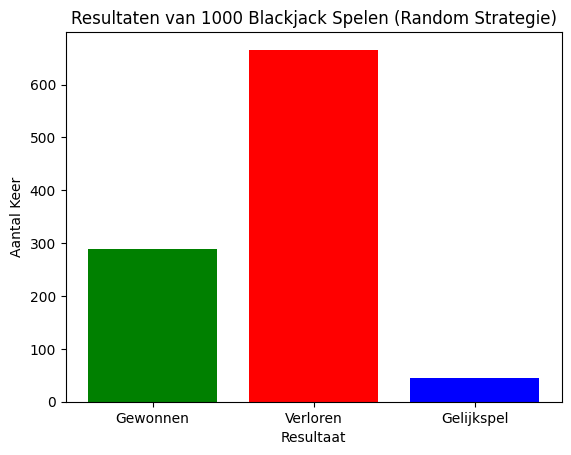

In [32]:
import matplotlib.pyplot as plt

labels = ['Gewonnen', 'Verloren', 'Gelijkspel']
counts = [results.count(label) for label in labels]
plt.bar(labels, counts, color=['green', 'red', 'blue'])
plt.title('Resultaten van 1000 Blackjack Spelen (Random Strategie)')
plt.xlabel('Resultaat')
plt.ylabel('Aantal Keer')
plt.show()